In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


After data is imported and displayed, check for null values.

In [67]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

Now display the statistical characteristics of data columns for future reference.

In [68]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


Now check what types of data prevails in the dataset.

In [69]:
df.dtypes

 Destination Port                int64
 Flow Duration                   int64
 Total Fwd Packets               int64
 Total Backward Packets          int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
 Idle Std                      float64
 Idle Max                        int64
 Idle Min                        int64
 Label                          object
Length: 79, dtype: object

Remove the null values.

In [70]:
df.dropna(inplace=True)
df.columns = df.columns.str.strip()

Plot the number of different port occurrences on the bar chart to recognize the most common port as well as unusual spikes in other ports. These would help in suspecting the DDoS attack port. 

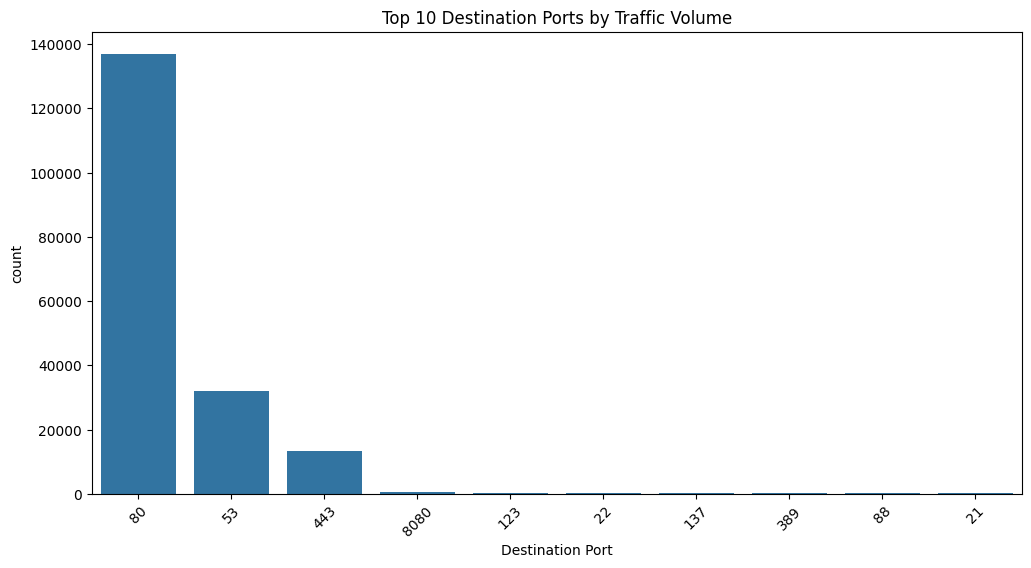

In [71]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Destination Port', data=df, order=df['Destination Port'].value_counts().iloc[:10].index)
plt.title('Top 10 Destination Ports by Traffic Volume')
plt.xticks(rotation=45)
plt.show()

Port 80, 53 and 443 were proven to be the most active ports throughout the period of DDoS attack.

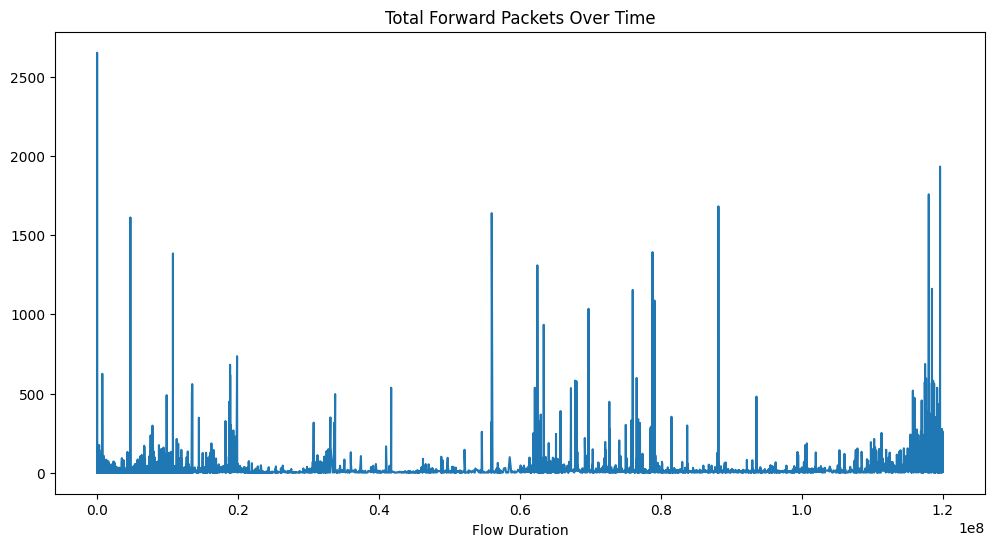

In [72]:
plt.figure(figsize=(12, 6))
df.groupby('Flow Duration')['Total Fwd Packets'].sum().plot()
plt.title('Total Forward Packets Over Time')
plt.show()

There are certain durations where the packet counts are consistently higher, such as around the 0.6e8 and 1.2e8 marks. These points could be worth investigating further to see if they correspond to known attacks or anomalies.

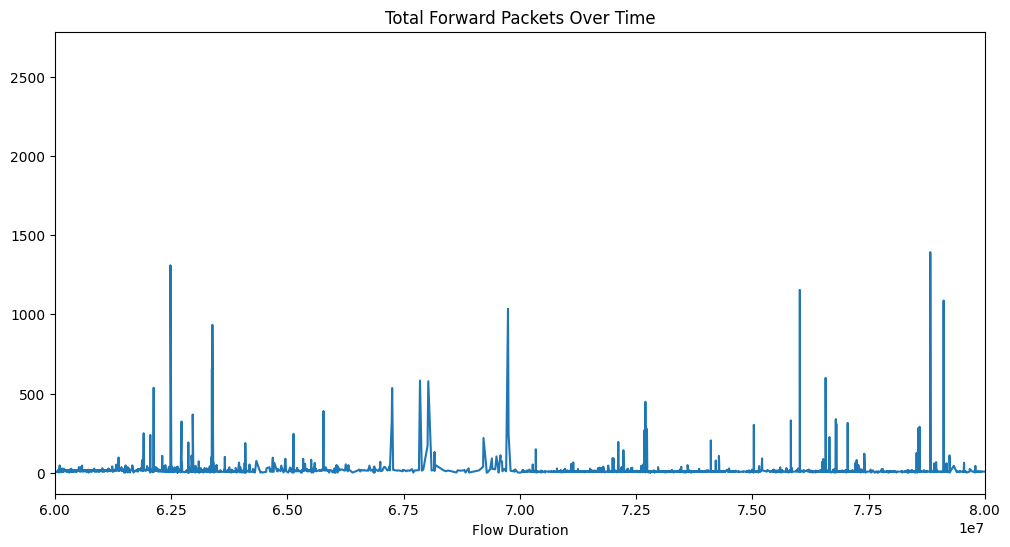

In [73]:
plt.figure(figsize=(12, 6))
df.groupby('Flow Duration')['Total Fwd Packets'].sum().plot()
plt.title('Total Forward Packets Over Time')
plt.xlim(0.6e8, 0.8e8)
plt.show()

1. Multiple Traffic Spikes:
There are several noticeable spikes in the number of forward packets, some reaching as high as 1000–2500 packets in a single flow duration. This irregularity and the height of these spikes could be indicative of a DDoS attack, where multiple requests are sent in a short period to overwhelm the system.
2. Potential Attack Patterns:
The pattern of these spikes, especially their periodic nature, could suggest coordinated attempts to flood the network, a common characteristic of DDoS attacks. It might indicate different waves of attack within this time frame.
3. Lower Baseline Activity:
Between these spikes, there appears to be a lower level of continuous activity. This could represent normal traffic, with the spikes being potential attack vectors.

Zoom in one of spike areas.

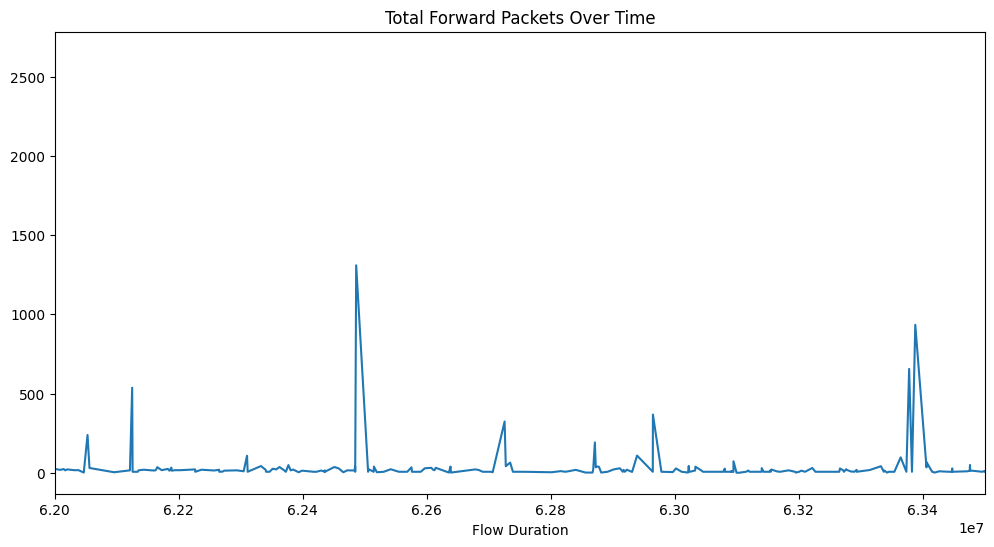

In [74]:
plt.figure(figsize=(12, 6))
df.groupby('Flow Duration')['Total Fwd Packets'].sum().plot()
plt.title('Total Forward Packets Over Time')
plt.xlim(0.62e8, 0.635e8)
plt.show()

/var/folders/vh/bm245h257v3b4516qc8yf9_m0000gn/T/ipykernel_28826/426547304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_80["Time Interval"] = pd.cut(df_no_80["Flow Duration"], bins = 50)


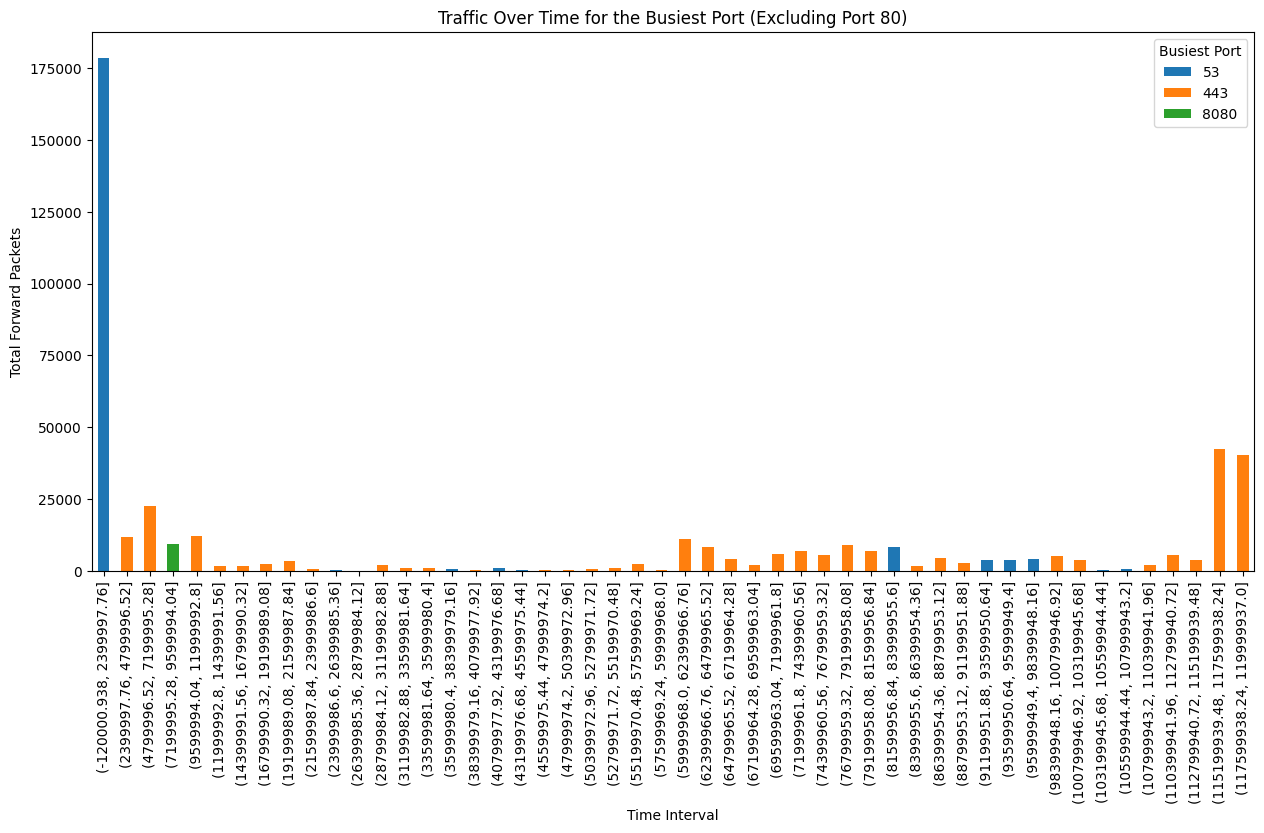

In [75]:
df_no_80 = df[df["Destination Port"] != 80]
df_no_80["Time Interval"] = pd.cut(df_no_80["Flow Duration"], bins = 50)
busiest_ports = df_no_80.groupby('Time Interval')['Destination Port'].apply(lambda x: x.value_counts().idxmax())
busiest_ports = busiest_ports.reset_index()
busiest_ports.columns = ['Time Interval', 'Busiest Port']

df_merged = pd.merge(df_no_80, busiest_ports, on="Time Interval")
traffic_over_time = df_merged.groupby(['Time Interval', 'Busiest Port'])['Total Fwd Packets'].sum().unstack()
traffic_over_time.plot(kind='bar', stacked=True, figsize=(15, 7))
plt.title('Traffic Over Time for the Busiest Port (Excluding Port 80)')
plt.xlabel('Time Interval')
plt.ylabel('Total Forward Packets')
plt.show()

The graph shows that traffic on port 53 dominates early on, but later intervals are dominated by port 443. This suggests a shift in the type of traffic or potentially a change in the attack vector (if this was malicious traffic).
Port 8080, while present, has less significant traffic compared to 53 and 443, indicating it was less targeted or less used during these periods. The sharp spikes on port 53 and 443 suggest periods of intense activity. Depending on the context, these could represent legitimate traffic bursts or DDoS attack phases.

We will return to the ports 53 and 443 later, as of now, let's also check the ratio between SYN flags and ACK flags because if there is a lot of unfinished handshakes, it can actually lead to the SYN flood attack.

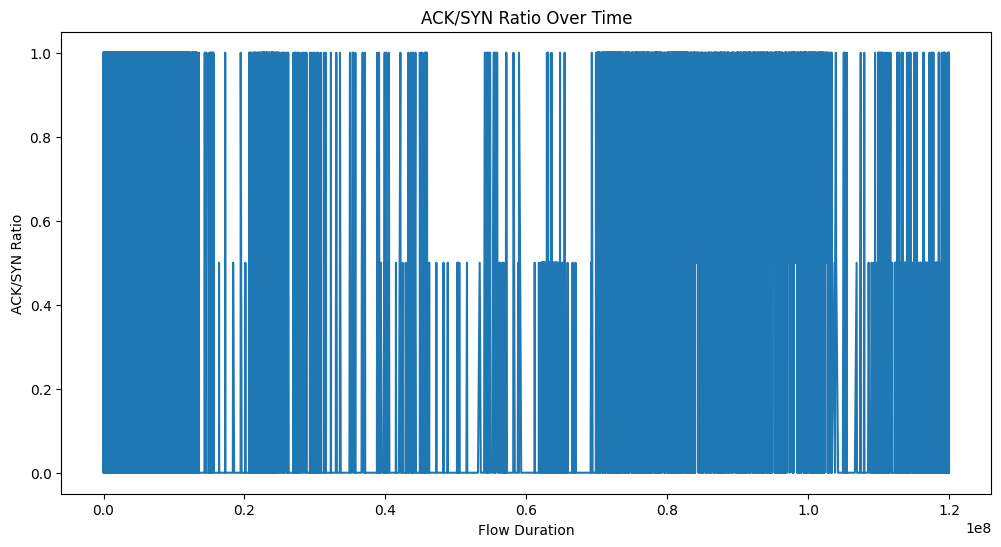

In [89]:
plt.figure(figsize=(12, 6))
df['ACK/SYN Ratio'] = df['ACK Flag Count'] / (df['SYN Flag Count'] + 1)
df.groupby('Flow Duration')['ACK/SYN Ratio'].mean().plot()
plt.title('ACK/SYN Ratio Over Time')
plt.xlabel('Flow Duration')
plt.ylabel('ACK/SYN Ratio')
plt.show()

The plot shows several periods where the ACK/SYN ratio drops close to zero, especially around the 5.5e7 mark. These low ratios strongly suggest that during these periods, SYN packets significantly outnumbered ACK packets, which is characteristic of a SYN flood attack.

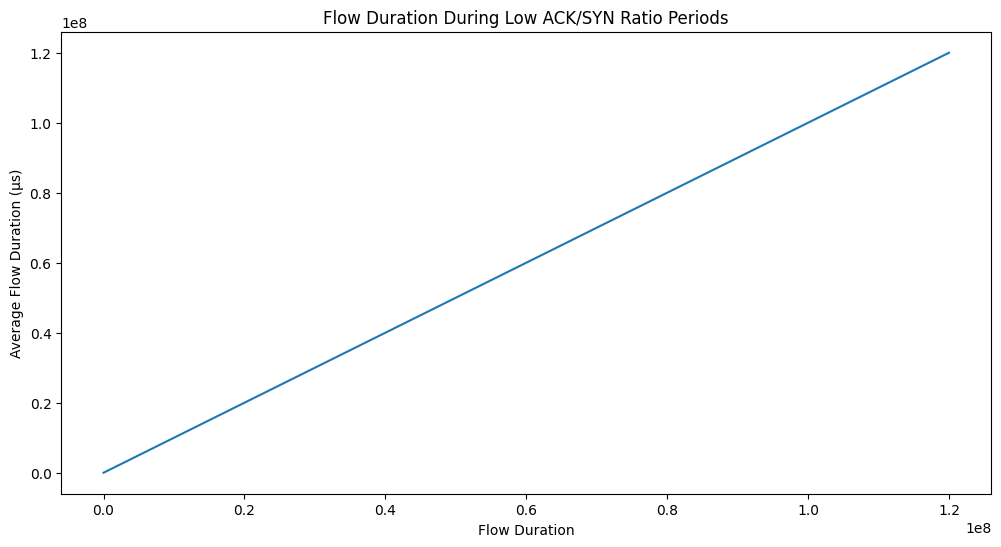

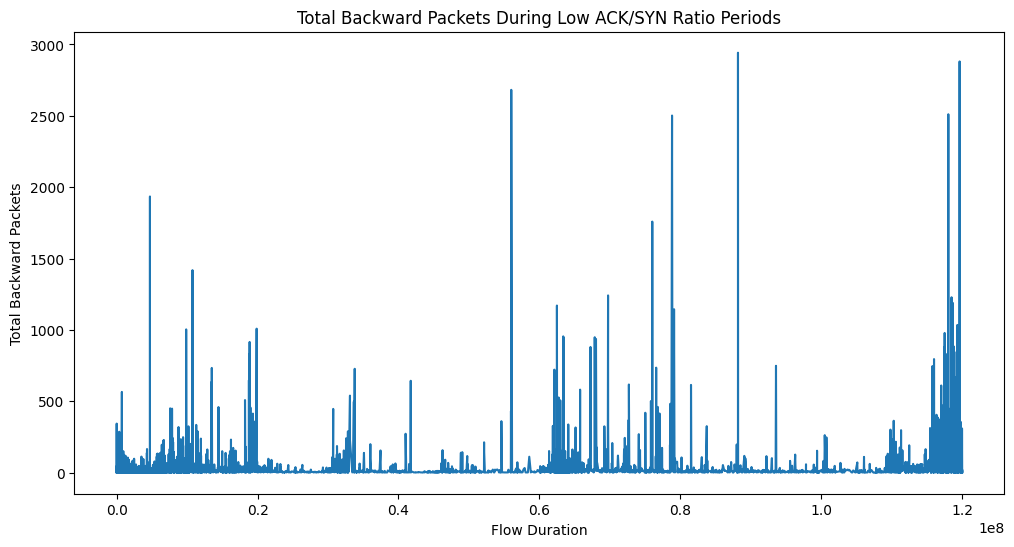

In [77]:
low_ack_syn_df = df[df['ACK/SYN Ratio'] < 0.6]

plt.figure(figsize=(12, 6))
low_ack_syn_df.groupby('Flow Duration')['Flow Duration'].mean().plot()
plt.title('Flow Duration During Low ACK/SYN Ratio Periods')
plt.xlabel('Flow Duration')
plt.ylabel('Average Flow Duration (µs)')
plt.show()

plt.figure(figsize=(12, 6))
low_ack_syn_df.groupby('Flow Duration')['Total Backward Packets'].sum().plot()
plt.title('Total Backward Packets During Low ACK/SYN Ratio Periods')
plt.xlabel('Flow Duration')
plt.ylabel('Total Backward Packets')
plt.show()

Increased Backward Packets: The spikes in backward packets could indicate that the server is attempting to deal with a flood of incoming SYN packets by sending out as many ACKs as it can, but might still be overwhelmed. This is common in a SYN flood attack where the server's resources are strained, leading to delayed or reduced responses.

Gaps in Backward Packets: The gaps or periods with low backward packets suggest times when the server might be too overwhelmed to respond, which aligns with the DDoS hypothesis.

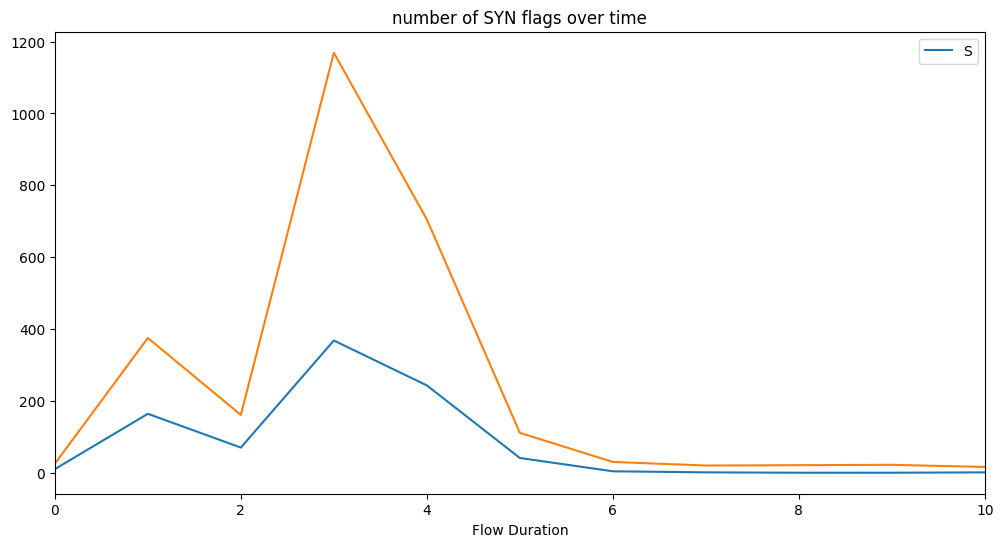

In [106]:
plt.figure(figsize=(12, 6))
df.groupby("Flow Duration")["SYN Flag Count"].sum().plot(label='SYN Flags')
df.groupby("Flow Duration")["ACK Flag Count"].sum().plot(label='ACK Flags')
plt.title("number of SYN flags over time")
plt.xlim(0.0e8, 0.0000001e8)
plt.show()

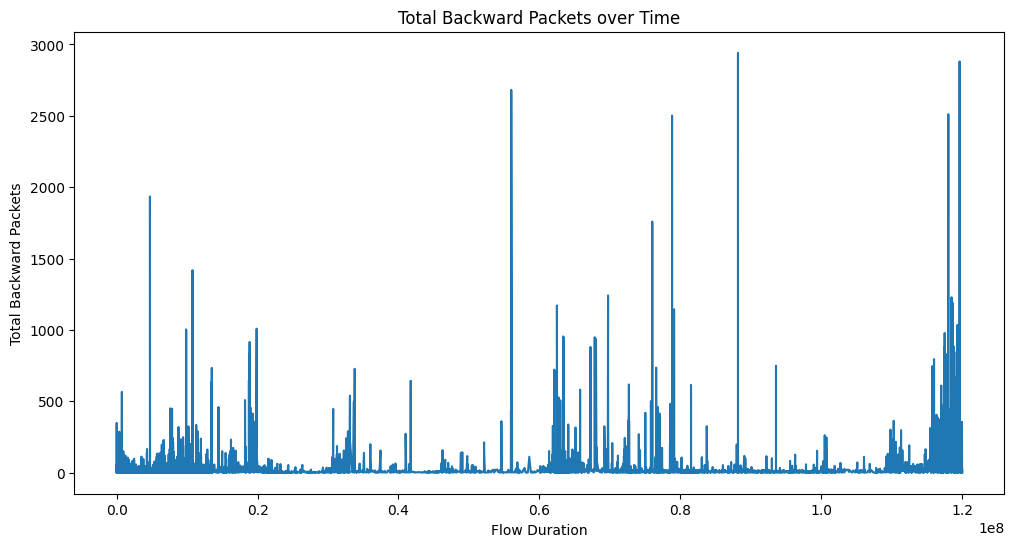

In [107]:
plt.figure(figsize = [ 12, 6 ])
df.groupby('Flow Duration')['Total Backward Packets'].sum().plot()
plt.title('Total Backward Packets over Time')
plt.xlabel('Flow Duration')
plt.ylabel('Total Backward Packets')
plt.show()

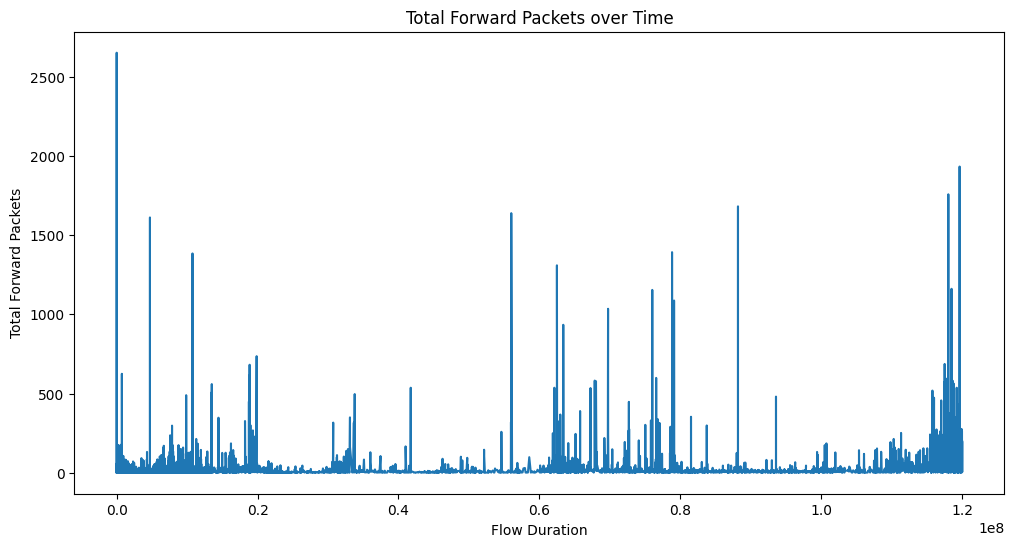

In [120]:
plt.figure(figsize = [ 12, 6 ])
df.groupby('Flow Duration')['Total Fwd Packets'].sum().plot()
plt.title('Total Forward Packets over Time')
plt.xlabel('Flow Duration')
plt.ylabel('Total Forward Packets')
plt.show()

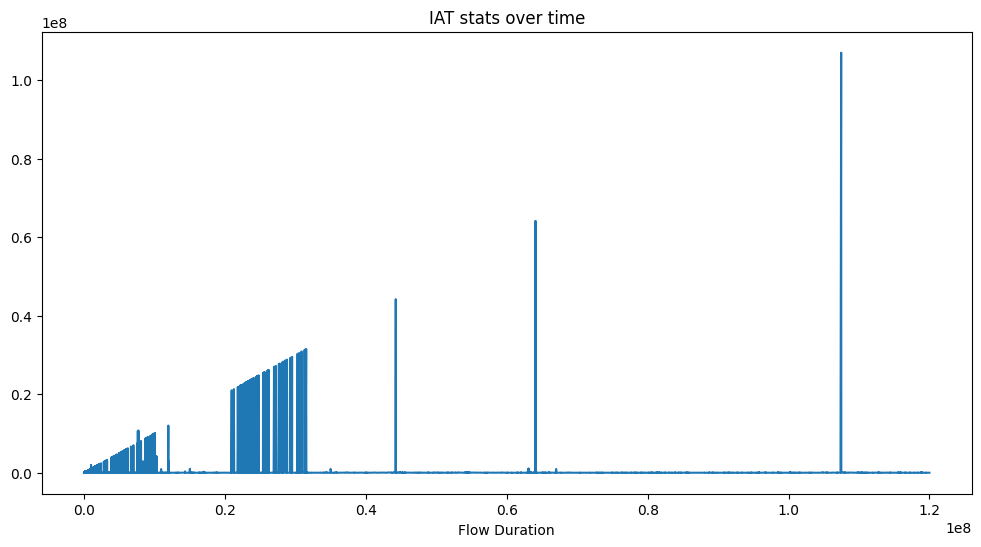

In [118]:
plt.figure(figsize=(12, 6))
#df.groupby("Flow Duration")["Flow IAT Mean"].sum().plot()
#df.groupby("Flow Duration")["Flow IAT Std"].sum().plot()
#df.groupby("Flow Duration")["Flow IAT Max"].sum().plot()
df.groupby("Flow Duration")["Flow IAT Min"].sum().plot()
plt.title("IAT stats over time")
plt.show()

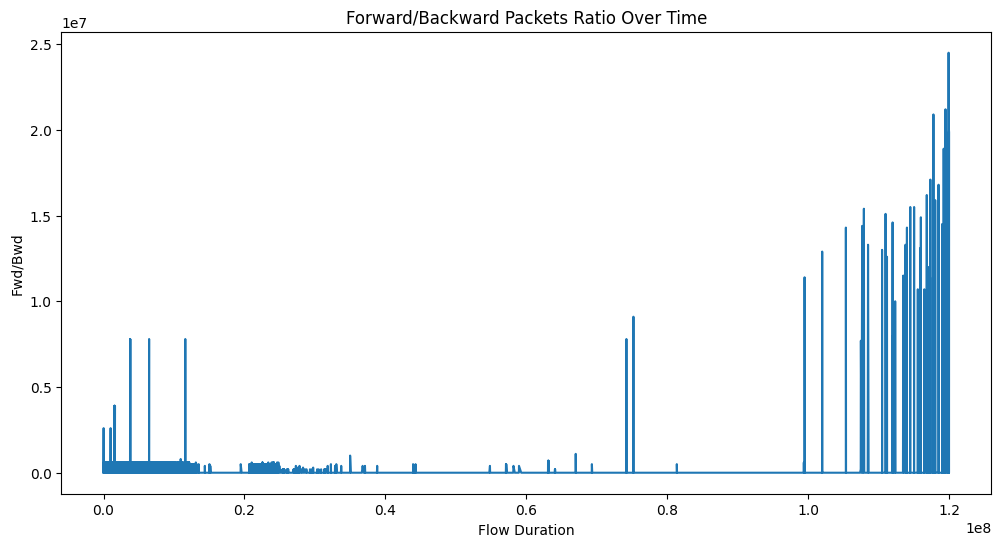

In [122]:
plt.figure(figsize=(12, 6))
df['Fwd/Bwd'] = df['Total Fwd Packets'] / (df['Total Backward Packets']+ 1e-5)
df.groupby('Flow Duration')['Fwd/Bwd'].mean().plot()
plt.title('Forward/Backward Packets Ratio Over Time')
plt.xlabel('Flow Duration')
plt.ylabel('Fwd/Bwd')
plt.show()

In [171]:
backward_packets_threshold = 500 
ratio_threshold = 0.75
df['Label'] = 0
df.loc[(df['Total Backward Packets'] > backward_packets_threshold) & (df['Fwd/Bwd'] < ratio_threshold), 'Label'] = 1

num_attack_samples = len(df[df["Label"] == 1])
num_normal_samples = len(df[df["Label"] == 0])

attack_samples = df[df['Label'] == 1].sample(num_attack_samples, random_state=42)
print(num_attack_samples)
normal_samples = df[df['Label'] == 0].sample(min(10, num_normal_samples), random_state=42)

print("Attack Samples:")
print(attack_samples[['Total Backward Packets', 'Total Fwd Packets', 'Fwd/Bwd']])

print("\nNormal Samples:")
print(normal_samples[['Total Backward Packets', 'Total Fwd Packets', 'Fwd/Bwd']])

42
Attack Samples:
        Total Backward Packets  Total Fwd Packets   Fwd/Bwd
209278                    2502               1392  0.556355
15443                      540                350  0.648148
204805                    1759               1154  0.656055
174898                    1190                581  0.488235
11253                      847                537  0.634002
40234                      578                203  0.351211
2099                       582                390  0.670103
223528                     728                497  0.682692
9783                       747                519  0.694779
155637                     509                327  0.642436
8349                       611                457  0.747954
110723                     527                324  0.614801
217557                    2682               1638  0.610738
13771                      881                535  0.607264
211611                     833                596  0.715486
217295               

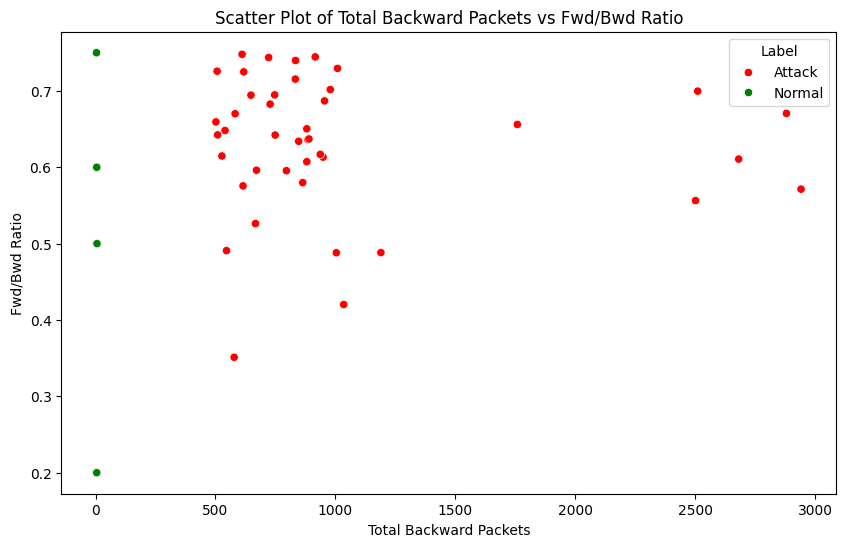

In [149]:
num_normal_samples = min(10, num_normal_samples)

filtered_normal_samples = normal_samples[normal_samples['Fwd/Bwd'] < ratio_threshold]

visualization_df = pd.concat([attack_samples, filtered_normal_samples])

# Create a scatter plot with corrected coloring
plt.figure(figsize=(10, 6))
sns.scatterplot(data=visualization_df, x='Total Backward Packets', y='Fwd/Bwd', hue='Label', palette={0: 'green', 1: 'red'})

# Add titles and labels
plt.title('Scatter Plot of Total Backward Packets vs Fwd/Bwd Ratio')
plt.xlabel('Total Backward Packets')
plt.ylabel('Fwd/Bwd Ratio')
plt.legend(title='Label', labels=['Attack', 'Normal'])
plt.show()

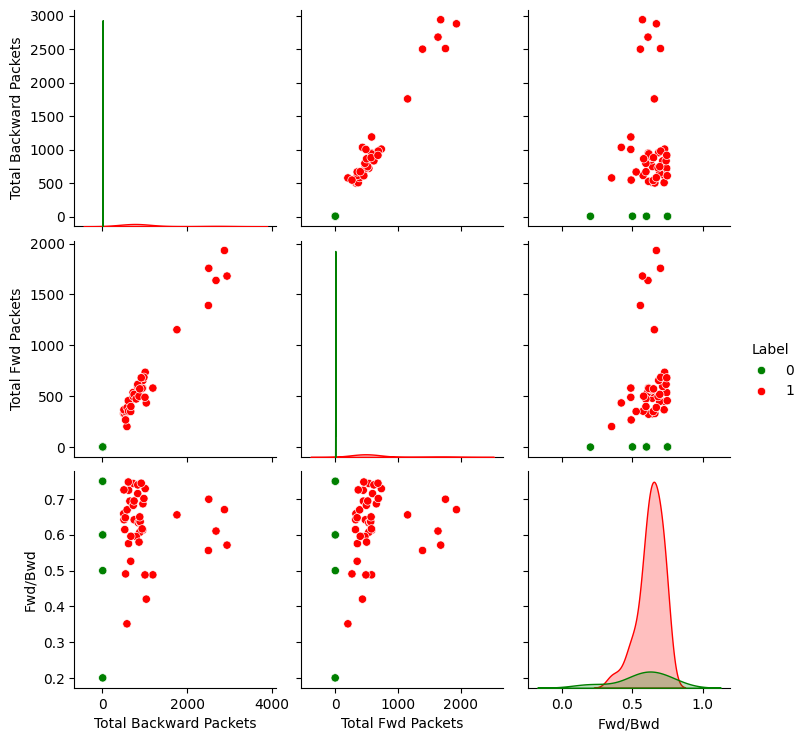

In [151]:
visualization_df = pd.concat([attack_samples, filtered_normal_samples])

# Select the features to plot
features = ['Total Backward Packets', 'Total Fwd Packets', 'Fwd/Bwd']

# Create a pair plot
sns.pairplot(visualization_df[features + ['Label']], hue='Label', palette={0: 'green', 1: 'red'}, diag_kind='kde')

# Show the plot
plt.show()

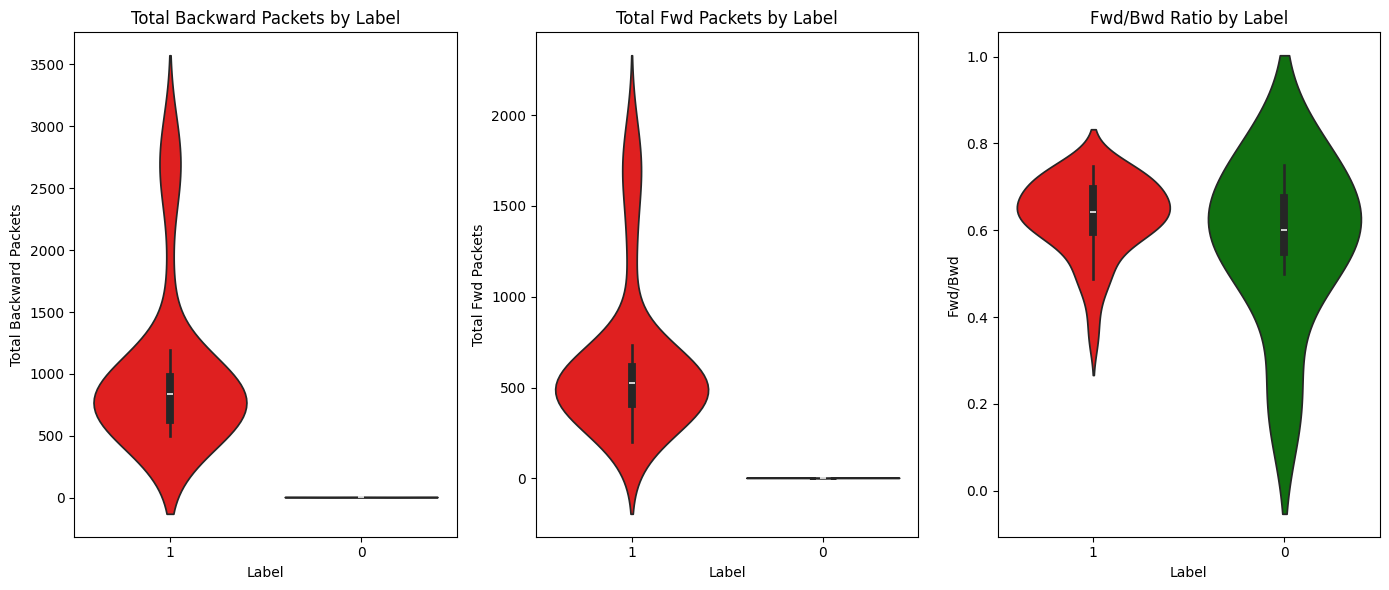

In [155]:
visualization_df = pd.concat([attack_samples, filtered_normal_samples])

# Convert the Label column to a string type
visualization_df['Label'] = visualization_df['Label'].astype(str)

plt.figure(figsize=(14, 6))

# Total Backward Packets
plt.subplot(1, 3, 1)
sns.violinplot(x='Label', y='Total Backward Packets', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'}, legend=False)
plt.title('Total Backward Packets by Label')

# Total Fwd Packets
plt.subplot(1, 3, 2)
sns.violinplot(x='Label', y='Total Fwd Packets', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'}, legend=False)
plt.title('Total Fwd Packets by Label')

# Fwd/Bwd Ratio
plt.subplot(1, 3, 3)
sns.violinplot(x='Label', y='Fwd/Bwd', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'}, legend=False)
plt.title('Fwd/Bwd Ratio by Label')

plt.tight_layout()
plt.show()

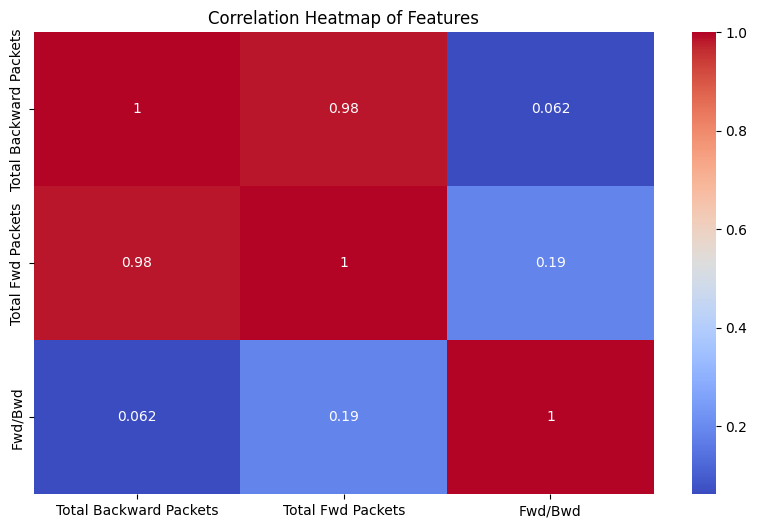

In [156]:
plt.figure(figsize=(10, 6))
sns.heatmap(visualization_df[features].corr(), annot=True, cmap='coolwarm')

# Add title
plt.title('Correlation Heatmap of Features')
plt.show()

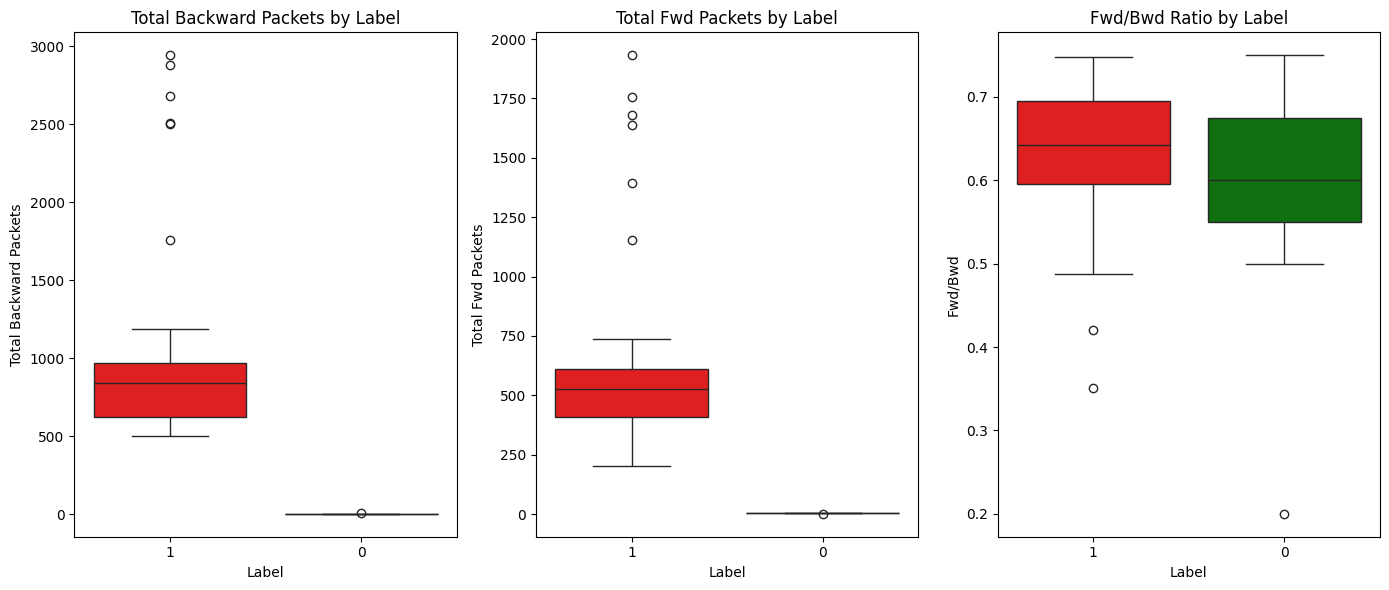

In [160]:
plt.figure(figsize=(14, 6))

# Total Backward Packets
plt.subplot(1, 3, 1)
sns.boxplot(x='Label', y='Total Backward Packets', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'})
plt.title('Total Backward Packets by Label')

# Total Fwd Packets
plt.subplot(1, 3, 2)
sns.boxplot(x='Label', y='Total Fwd Packets', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'})
plt.title('Total Fwd Packets by Label')

# Fwd/Bwd Ratio
plt.subplot(1, 3, 3)
sns.boxplot(x='Label', y='Fwd/Bwd', data=visualization_df, hue='Label', palette={'0': 'green', '1': 'red'})
plt.title('Fwd/Bwd Ratio by Label')

plt.tight_layout()
plt.show()

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.concat([attack_samples, filtered_normal_samples])
X = df[['Total Backward Packets', 'Total Fwd Packets', 'Fwd/Bwd']]
y = df['Label'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialise the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

In [163]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred, target_names=['Normal', 'Attack'])
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[3 0]
 [0 7]]
Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         3
      Attack       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [166]:
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to generate more attack samples
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, y_pred, target_names=['Normal', 'Attack'])
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[8 0]
 [0 9]]
Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         8
      Attack       1.00      1.00      1.00         9

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



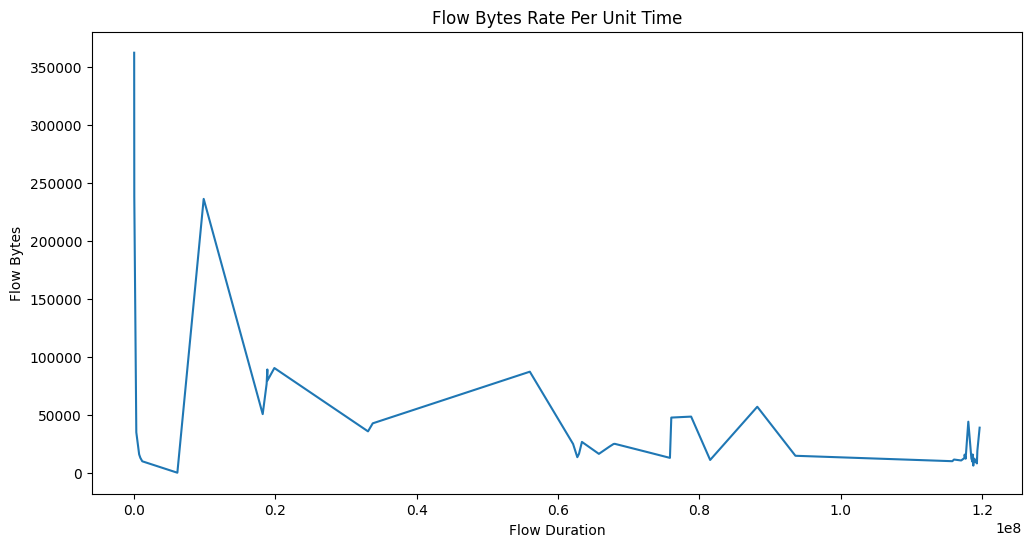

In [181]:
plt.figure(figsize=(12, 6))
df.groupby("Flow Duration")["Flow Bytes/s"].mean().plot()
plt.title("Flow Bytes Rate Per Unit Time")
plt.xlabel("Flow Duration")
plt.ylabel("Flow Bytes")
plt.show()

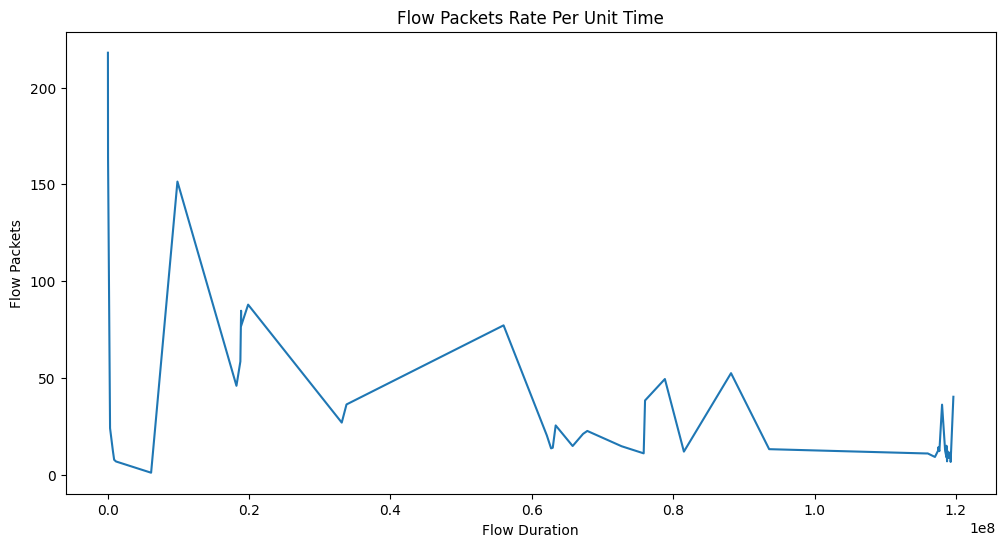

In [185]:
plt.figure(figsize=(12, 6))
df.groupby("Flow Duration")["Flow Packets/s"].mean().plot()
plt.title("Flow Packets Rate Per Unit Time")
plt.xlabel("Flow Duration")
plt.ylabel("Flow Packets")
plt.show()